In [1]:
import netCDF4 as nc
import numpy as np
import xarray as xr
import warnings
from eofs.xarray import Eof
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import seaborn as sns
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from proj_utils import *
from mapping_utils import *


## Load files and sort out time series

In [2]:
fig_path  = '/Users/lillienders/Documents/gs_var/figures/'
data_path = '/Users/lillienders/Documents/gs_var/data/'

In [3]:
gsi_uf  = xr.open_dataarray(data_path + 'gsi/alt_gsi_24.nc')
gsi_f   = lanczos_bandpass(gsi_uf, low_freq = 12*6, high_freq = 12*11, window = 12) 
gsi_f   = (gsi_f - gsi_f.mean(dim='time'))/gsi_f.std(dim = 'time')

In [4]:
f_path = '/Users/lillienders/Documents/gs_var/data/climate_fields/'
f_name = 'slp.nc'
slp_ds = xr.open_dataset(f_path + f_name)
slp    = slp_ds['msl']

In [6]:
eofs_full, pcs_full, per_var_full = calc_eofs(slp, num_modes=4)

/Users/lillienders/Documents/gs_var/proj_utils.py:317: RuntimeWarning: invalid value encountered in sqrt
  wgts = np.sqrt(coslat)[..., np.newaxis]


In [7]:
nao_uf = -pcs_full[:,0]
nao_f  = lanczos_bandpass(nao_uf, low_freq = 12*6, high_freq = 12*11, window = 12) 
nao_f  = (nao_f - nao_f.mean(dim='time'))/nao_f.std(dim = 'time')

In [8]:
eap_uf = -pcs_full[:,1]
eap_f  = lanczos_bandpass(eap_uf, low_freq = 12*6, high_freq = 12*11, window = 12) 
eap_f  = (eap_f - eap_f.mean(dim='time'))/eap_f.std(dim = 'time')

In [9]:
gsi_f = gsi_f[~np.isnan(gsi_f)]
nao_f = nao_f[~np.isnan(nao_f)]
eap_f = eap_f[~np.isnan(eap_f)]

### Calc moving averages (vary window size)

In [10]:
def moving_corr(nao_f, gsi_f, lag_gs = 7, chunk_sz = 48):
    corrs_ = []
    uci_ = []; lci_ = [];
    for c in range(len(gsi_f)-(chunk_sz+lag_gs)):
        corrs_.append(np.corrcoef(nao_f[c:c+chunk_sz],gsi_f[lag_gs+c:lag_gs+c+chunk_sz])[0,1])
        lci_temp, uci_temp = get_cis(nao_f[c:c+chunk_sz],gsi_f[lag_gs+c:lag_gs+c+chunk_sz],0)
        lci_.append(lci_temp)
        uci_.append(uci_temp)
    return(corrs_, lci_, uci_)

## NAO WINDOW SIZE

In [30]:
chunks_to_try = np.arange(24,121,12)
corrs_ = np.zeros((len(chunks_to_try),len(gsi_f))); corrs_[:] = np.nan
uci_   = np.zeros((len(chunks_to_try),len(gsi_f))); uci_[:]   = np.nan
lci_   = np.zeros((len(chunks_to_try),len(gsi_f))); lci_[:]   = np.nan
lag_gs = 7

for ch in range(len(chunks_to_try)):
    print(chunks_to_try[ch])
    chunk_sz = chunks_to_try[ch]
    corrs_temp, lci_temp, uci_temp = moving_corr(nao_f, gsi_f, lag_gs, chunk_sz)
    corrs_temp.extend([np.nan] * (len(gsi_f) - len(corrs_temp)))
    corrs_[ch,:] = corrs_temp
    lci_temp = np.squeeze(np.stack(lci_temp)); uci_temp = np.squeeze(np.stack(uci_temp))
    lci_[ch,:] = np.pad(uci_temp, pad_width= (0,(len(gsi_f) - len(uci_temp))), constant_values=np.nan)
    uci_[ch,:] = np.pad(lci_temp, pad_width= (0,(len(gsi_f) - len(lci_temp))), constant_values=np.nan)

24
36
48
60
72
84
96
108
120


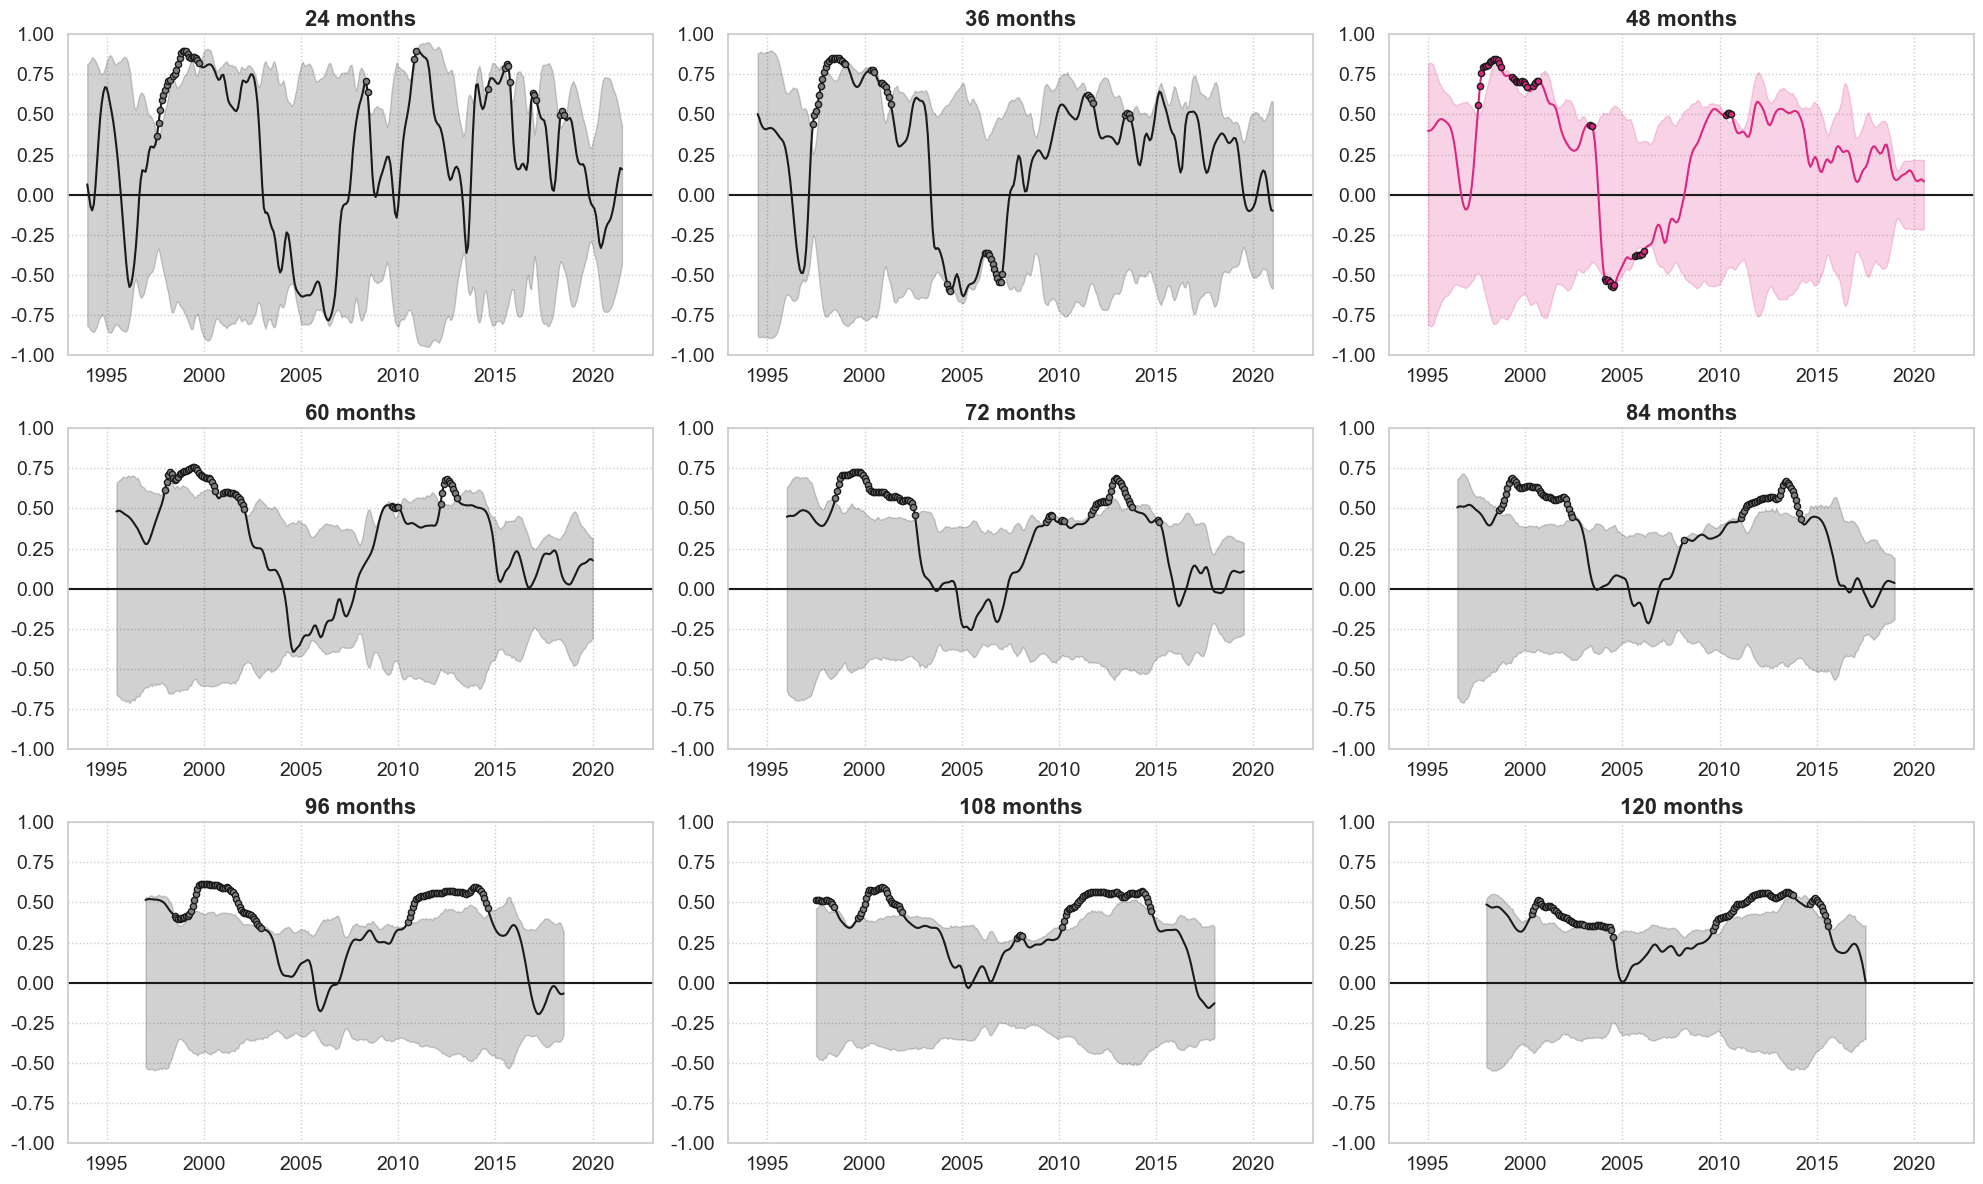

In [31]:
c = np.array(('k','k','#dc267f','k','k','k','k','k','k'))
sc = np.array(('grey','grey','#dc267f','grey','grey','grey','grey','grey','grey'))

sns.set_style('whitegrid',{"grid.linestyle": ":"})
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))
for row in range(3):
    for col in range(3):
        ch = row*3+col
        corr_temp = corrs_[ch,:][~np.isnan(corrs_[ch,:])]
        uci_temp  = uci_[ch,:][~np.isnan(uci_[ch,:])]
        lci_temp  = lci_[ch,:][~np.isnan(lci_[ch,:])]

        ix_ = []
        for l in range(len(corr_temp)):
            if corr_temp[l] < uci_temp[l] or corr_temp[l] > lci_temp[l]:
                ix_.append(l)
        ix_ = np.array(ix_)
        corr_temp = np.array(corr_temp)
        
        av_per    = len(gsi_f)-len(corr_temp)-lag_gs
        ax[row, col].axhline(0, color='k', linewidth=1.5)
        ax[row, col].plot(gsi_f.time[av_per//2:-av_per//2-lag_gs],corr_temp,color = c[ch])
        ax[row, col].fill_between(gsi_f.time[av_per//2:-av_per//2-lag_gs],lci_temp,uci_temp,color = c[ch],alpha = 0.2)
        ax[row, col].scatter(gsi_f.time[av_per//2:-av_per//2-lag_gs][ix_], corr_temp[ix_], s=20, color = sc[ch],edgecolors='k',zorder = 10)
        
        ax[row, col].set_xticks(gsi_f.time[2*12::5*12], labels = np.array(('1995','2000','2005','2010','2015','2020')), fontsize = 14)
        ax[row, col].set_yticks(np.arange(-1,1.25,0.25), labels = np.array(('-1.00','-0.75','-0.50','-0.25','0.00','0.25','0.50','0.75','1.00')), fontsize = 14)
        ax[row, col].set_xlim(gsi_f.time[0],gsi_f.time[-1])
        ax[row, col].set_ylim(-1,1)
        ax[row, col].set_title(str(chunks_to_try[ch]) + ' months', fontsize = 16, fontweight='bold')

plt.tight_layout()
plt.savefig(fig_path + 'nao_window_size_sensitivity.png', format='png', bbox_inches="tight",dpi=500)
plt.show()

## EAP WINDOW SIZE

In [32]:
chunks_to_try = np.arange(24,121,12)
corrs_ = np.zeros((len(chunks_to_try),len(gsi_f))); corrs_[:] = np.nan
uci_   = np.zeros((len(chunks_to_try),len(gsi_f))); uci_[:]   = np.nan
lci_   = np.zeros((len(chunks_to_try),len(gsi_f))); lci_[:]   = np.nan
lag_gs = 7

for ch in range(len(chunks_to_try)):
    print(chunks_to_try[ch])
    chunk_sz = chunks_to_try[ch]
    corrs_temp, lci_temp, uci_temp = moving_corr(eap_f, gsi_f, lag_gs, chunk_sz)
    corrs_temp.extend([np.nan] * (len(gsi_f) - len(corrs_temp)))
    corrs_[ch,:] = corrs_temp
    lci_temp = np.squeeze(np.stack(lci_temp)); uci_temp = np.squeeze(np.stack(uci_temp))
    lci_[ch,:] = np.pad(uci_temp, pad_width= (0,(len(gsi_f) - len(uci_temp))), constant_values=np.nan)
    uci_[ch,:] = np.pad(lci_temp, pad_width= (0,(len(gsi_f) - len(lci_temp))), constant_values=np.nan)

24
36
48
60
72
84
96
108
120


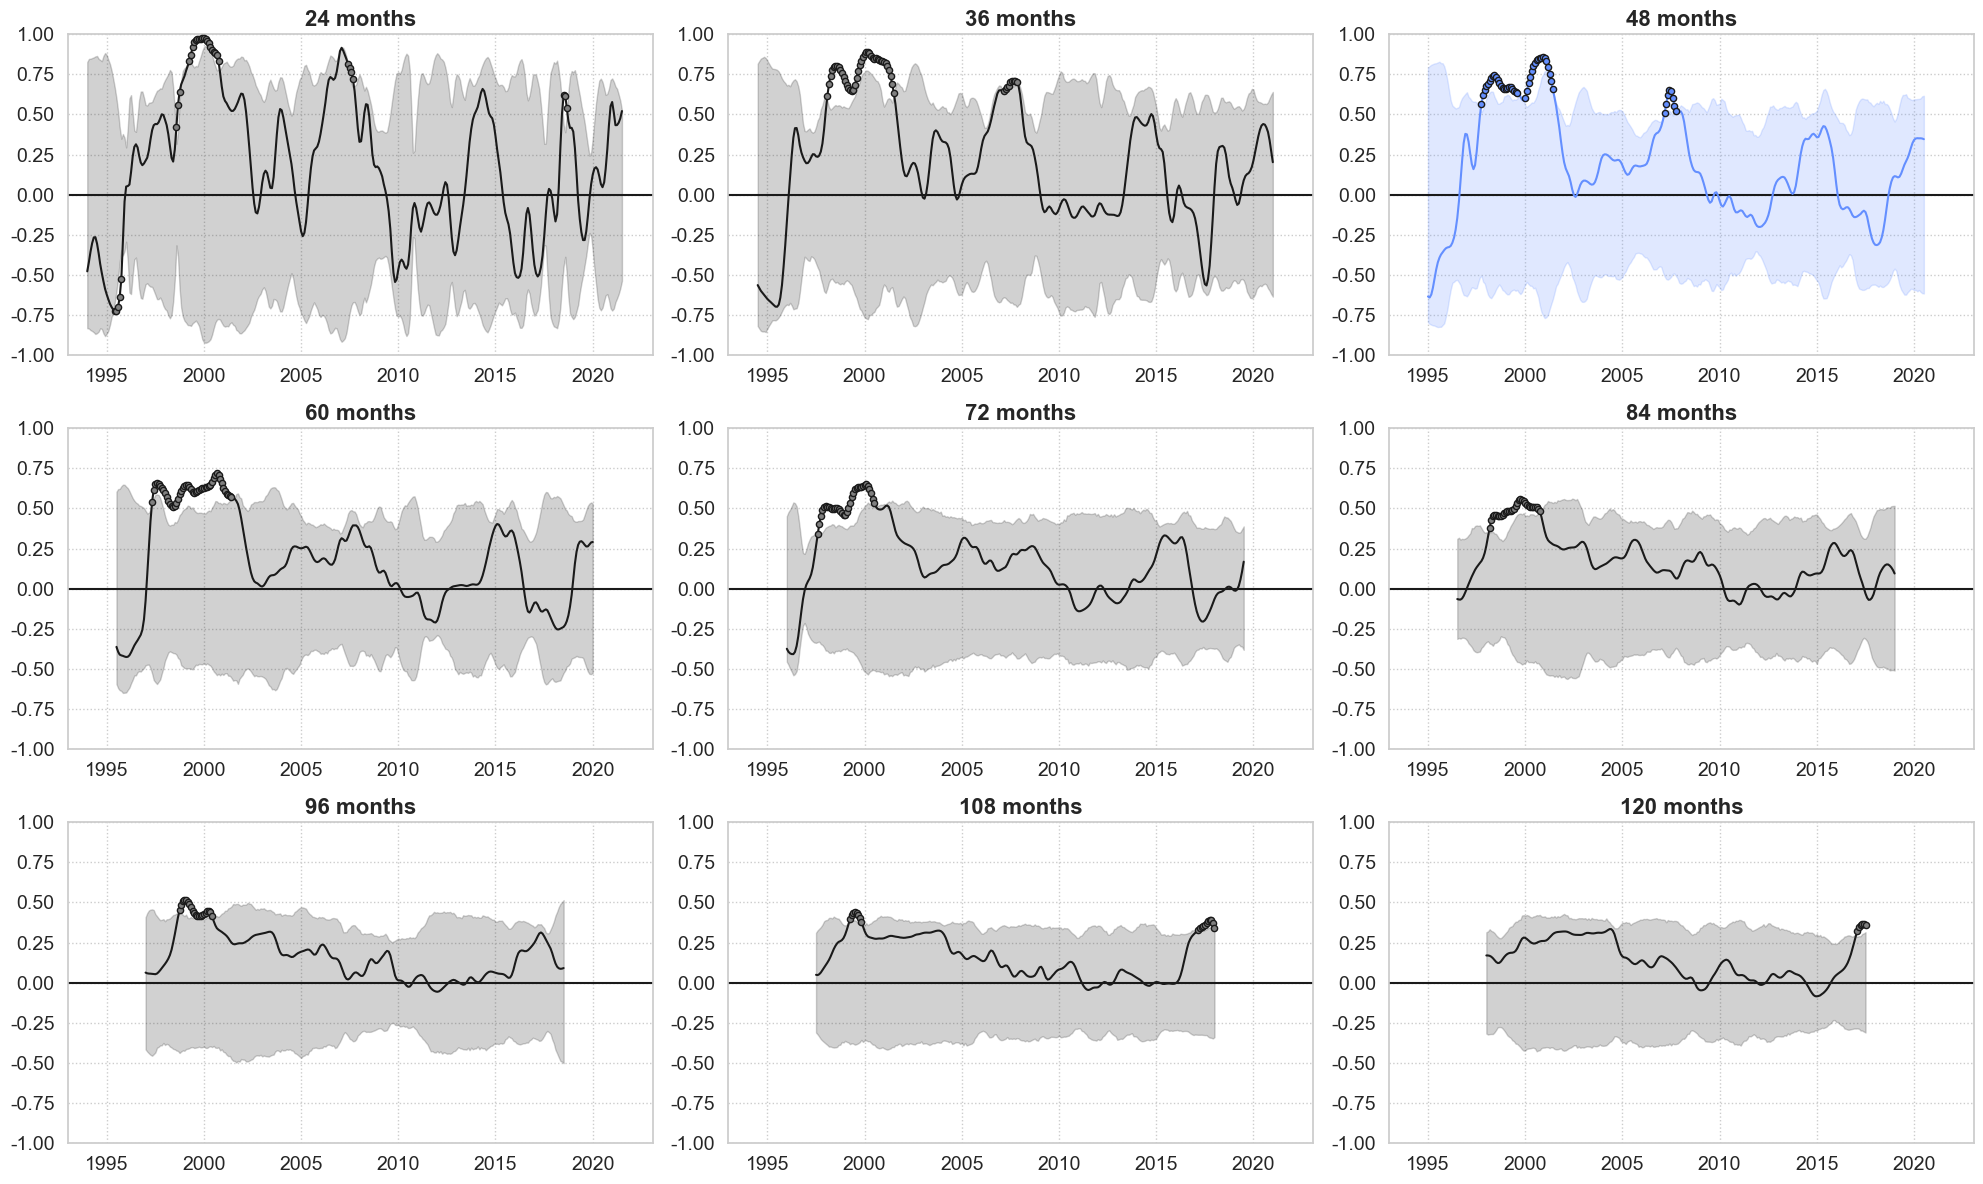

In [33]:
c = np.array(('k','k','#648fff','k','k','k','k','k','k'))
sc = np.array(('grey','grey','#648fff','grey','grey','grey','grey','grey','grey'))

sns.set_style('whitegrid',{"grid.linestyle": ":"})
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))
for row in range(3):
    for col in range(3):
        ch = row*3+col
        corr_temp = corrs_[ch,:][~np.isnan(corrs_[ch,:])]
        uci_temp  = uci_[ch,:][~np.isnan(uci_[ch,:])]
        lci_temp  = lci_[ch,:][~np.isnan(lci_[ch,:])]

        ix_ = []
        for l in range(len(corr_temp)):
            if corr_temp[l] < uci_temp[l] or corr_temp[l] > lci_temp[l]:
                ix_.append(l)
        ix_ = np.array(ix_)
        corr_temp = np.array(corr_temp)
        
        av_per    = len(gsi_f)-len(corr_temp)-lag_gs
        ax[row, col].axhline(0, color='k', linewidth=1.5)
        ax[row, col].plot(gsi_f.time[av_per//2:-av_per//2-lag_gs],corr_temp,color = c[ch])
        ax[row, col].fill_between(gsi_f.time[av_per//2:-av_per//2-lag_gs],lci_temp,uci_temp,color = c[ch],alpha = 0.2)
        ax[row, col].scatter(gsi_f.time[av_per//2:-av_per//2-lag_gs][ix_], corr_temp[ix_], s=20, color = sc[ch],edgecolors='k',zorder = 10)
        
        ax[row, col].set_xticks(gsi_f.time[2*12::5*12], labels = np.array(('1995','2000','2005','2010','2015','2020')), fontsize = 14)
        ax[row, col].set_yticks(np.arange(-1,1.25,0.25), labels = np.array(('-1.00','-0.75','-0.50','-0.25','0.00','0.25','0.50','0.75','1.00')), fontsize = 14)
        ax[row, col].set_xlim(gsi_f.time[0],gsi_f.time[-1])
        ax[row, col].set_ylim(-1,1)
        ax[row, col].set_title(str(chunks_to_try[ch]) + ' months', fontsize = 16, fontweight='bold')

plt.tight_layout()
plt.savefig(fig_path + 'eap_window_size_sensitivity.png', format='png', bbox_inches="tight",dpi=500)
plt.show()

## NAO LAG

In [34]:
lags_to_try = abs(np.arange(-12,-3))
corrs_   = np.zeros((len(lags_to_try),len(gsi_f))); corrs_[:] = np.nan
uci_     = np.zeros((len(lags_to_try),len(gsi_f))); uci_[:]   = np.nan
lci_     = np.zeros((len(lags_to_try),len(gsi_f))); lci_[:]   = np.nan
chunk_sz = 48

for l in range(len(lags_to_try)):
    print(lags_to_try[l])
    lag_gs = lags_to_try[l]
    corrs_temp, lci_temp, uci_temp = moving_corr(nao_f, gsi_f, lags_to_try[l], chunk_sz)
    corrs_temp.extend([np.nan] * (len(gsi_f) - len(corrs_temp)))
    corrs_[l,:] = corrs_temp
    lci_temp = np.squeeze(np.stack(lci_temp)); uci_temp = np.squeeze(np.stack(uci_temp))
    lci_[l,:] = np.pad(uci_temp, pad_width= (0,(len(gsi_f) - len(uci_temp))), constant_values=np.nan)
    uci_[l,:] = np.pad(lci_temp, pad_width= (0,(len(gsi_f) - len(lci_temp))), constant_values=np.nan)

12
11
10
9
8
7
6
5
4


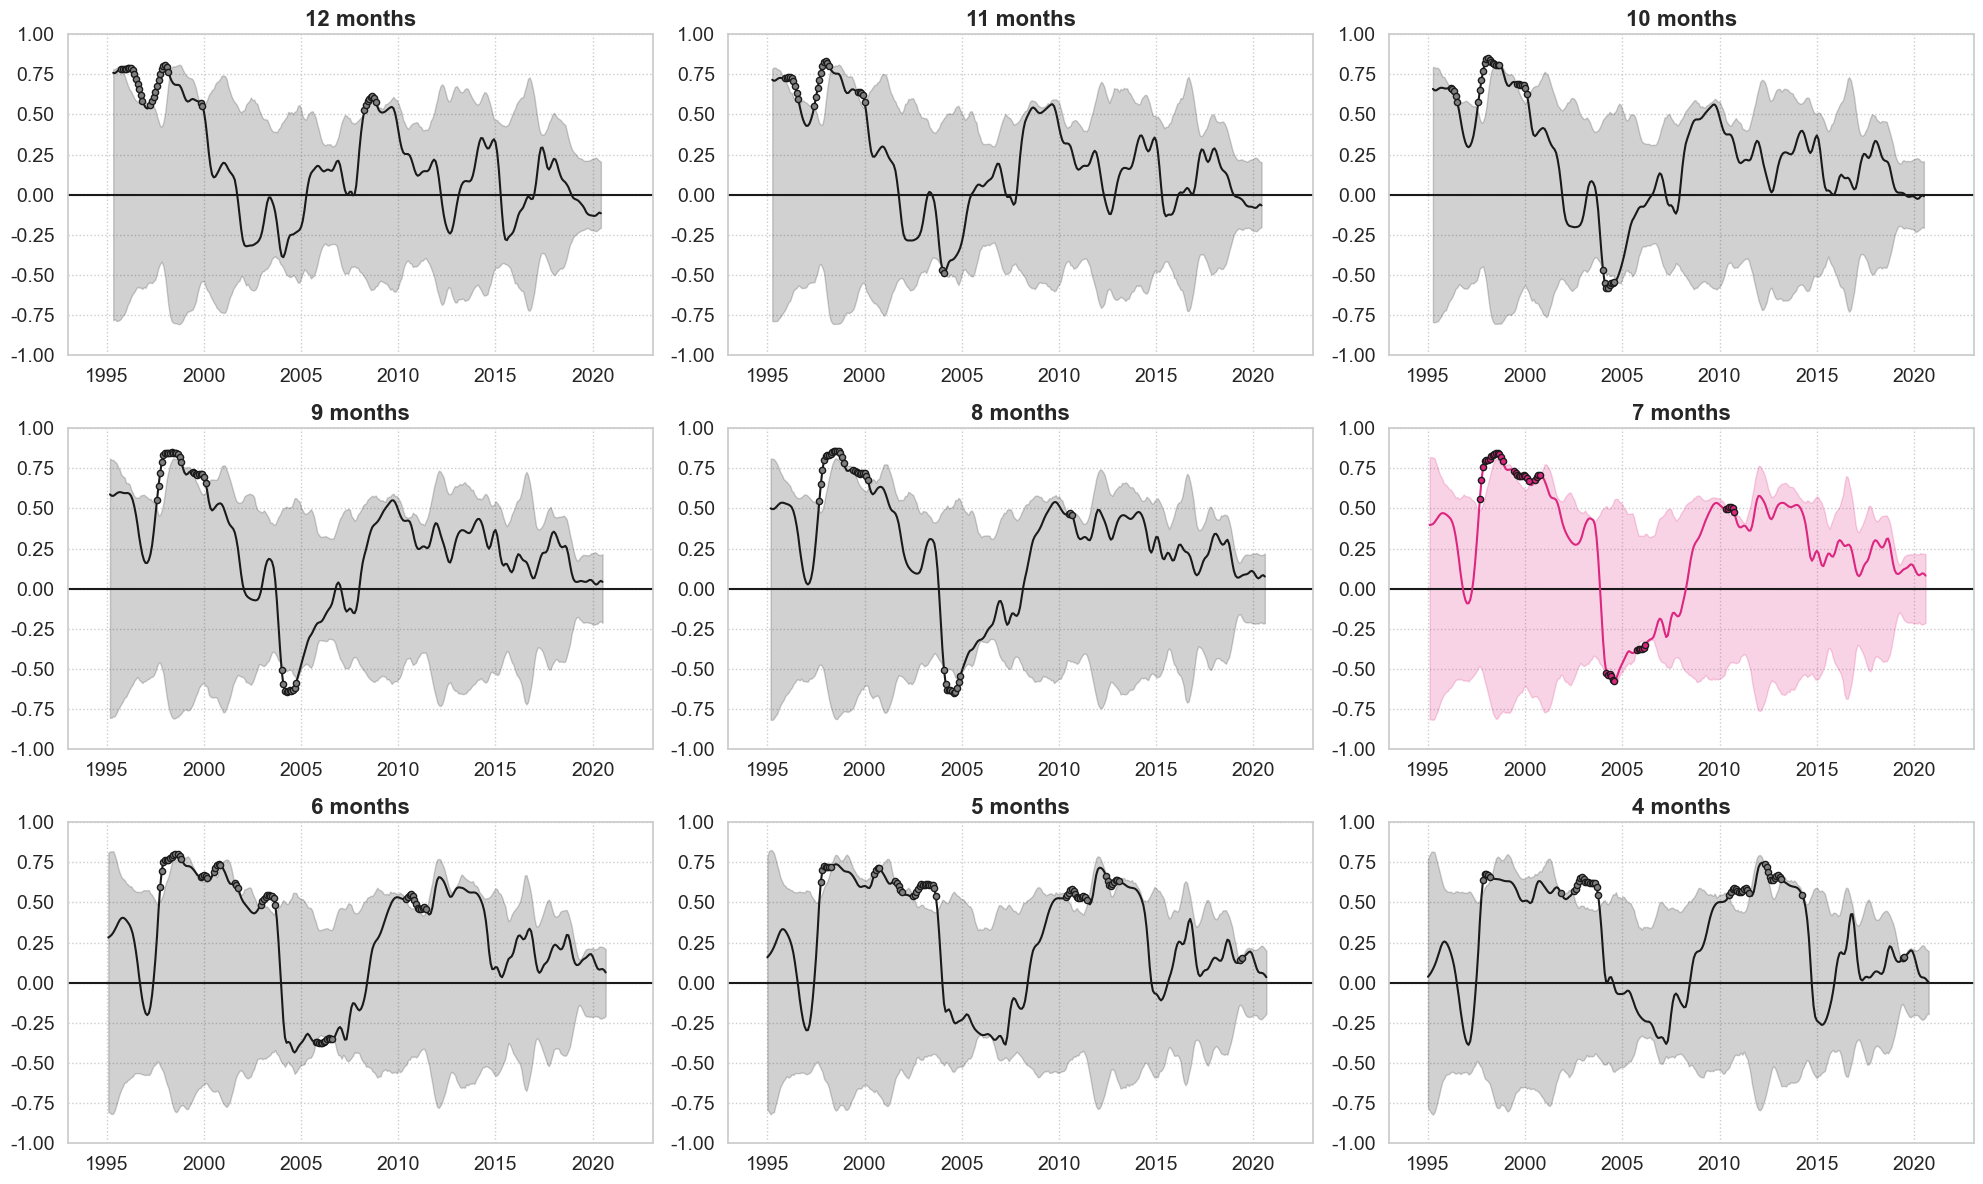

In [35]:
c = np.array(('k','k','k','k','k','#dc267f','k','k','k'))
sc = np.array(('grey','grey','grey','grey','grey','#dc267f','grey','grey','grey'))

sns.set_style('whitegrid',{"grid.linestyle": ":"})
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))
for row in range(3):
    for col in range(3):
        ch = row*3+col
        corr_temp = corrs_[ch,:][~np.isnan(corrs_[ch,:])]
        uci_temp  = uci_[ch,:][~np.isnan(uci_[ch,:])]
        lci_temp  = lci_[ch,:][~np.isnan(lci_[ch,:])]

        ix_ = []
        for l in range(len(corr_temp)):
            if corr_temp[l] < uci_temp[l] or corr_temp[l] > lci_temp[l]:
                ix_.append(l)
        ix_ = np.array(ix_)
        corr_temp = np.array(corr_temp)
        
        av_per    = len(gsi_f)-len(corr_temp)-lag_gs
        ax[row, col].axhline(0, color='k', linewidth=1.5)
        ax[row, col].plot(gsi_f.time[av_per//2:-av_per//2-lag_gs],corr_temp,color = c[ch])
        ax[row, col].fill_between(gsi_f.time[av_per//2:-av_per//2-lag_gs],lci_temp,uci_temp,color = c[ch],alpha = 0.2)
        ax[row, col].scatter(gsi_f.time[av_per//2:-av_per//2-lag_gs][ix_], corr_temp[ix_], s=20, color = sc[ch],edgecolors='k',zorder = 10)
        
        ax[row, col].set_xticks(gsi_f.time[2*12::5*12], labels = np.array(('1995','2000','2005','2010','2015','2020')), fontsize = 14)
        ax[row, col].set_yticks(np.arange(-1,1.25,0.25), labels = np.array(('-1.00','-0.75','-0.50','-0.25','0.00','0.25','0.50','0.75','1.00')), fontsize = 14)
        ax[row, col].set_xlim(gsi_f.time[0],gsi_f.time[-1])
        ax[row, col].set_ylim(-1,1)
        ax[row, col].set_title(str(lags_to_try[ch]) + ' months', fontsize = 16, fontweight='bold')

plt.tight_layout()
plt.savefig(fig_path + 'nao_lag_sensitivity.png', format='png', bbox_inches="tight",dpi=500)
plt.show()

## EAP LAG

In [36]:
lags_to_try = abs(np.arange(-12,-3))
corrs_   = np.zeros((len(lags_to_try),len(gsi_f))); corrs_[:] = np.nan
uci_     = np.zeros((len(lags_to_try),len(gsi_f))); uci_[:]   = np.nan
lci_     = np.zeros((len(lags_to_try),len(gsi_f))); lci_[:]   = np.nan
chunk_sz = 48

for l in range(len(lags_to_try)):
    print(lags_to_try[l])
    lag_gs = lags_to_try[l]
    corrs_temp, lci_temp, uci_temp = moving_corr(eap_f, gsi_f, lags_to_try[l], chunk_sz)
    corrs_temp.extend([np.nan] * (len(gsi_f) - len(corrs_temp)))
    corrs_[l,:] = corrs_temp
    lci_temp = np.squeeze(np.stack(lci_temp)); uci_temp = np.squeeze(np.stack(uci_temp))
    lci_[l,:] = np.pad(uci_temp, pad_width= (0,(len(gsi_f) - len(uci_temp))), constant_values=np.nan)
    uci_[l,:] = np.pad(lci_temp, pad_width= (0,(len(gsi_f) - len(lci_temp))), constant_values=np.nan)

12
11
10
9
8
7
6
5
4


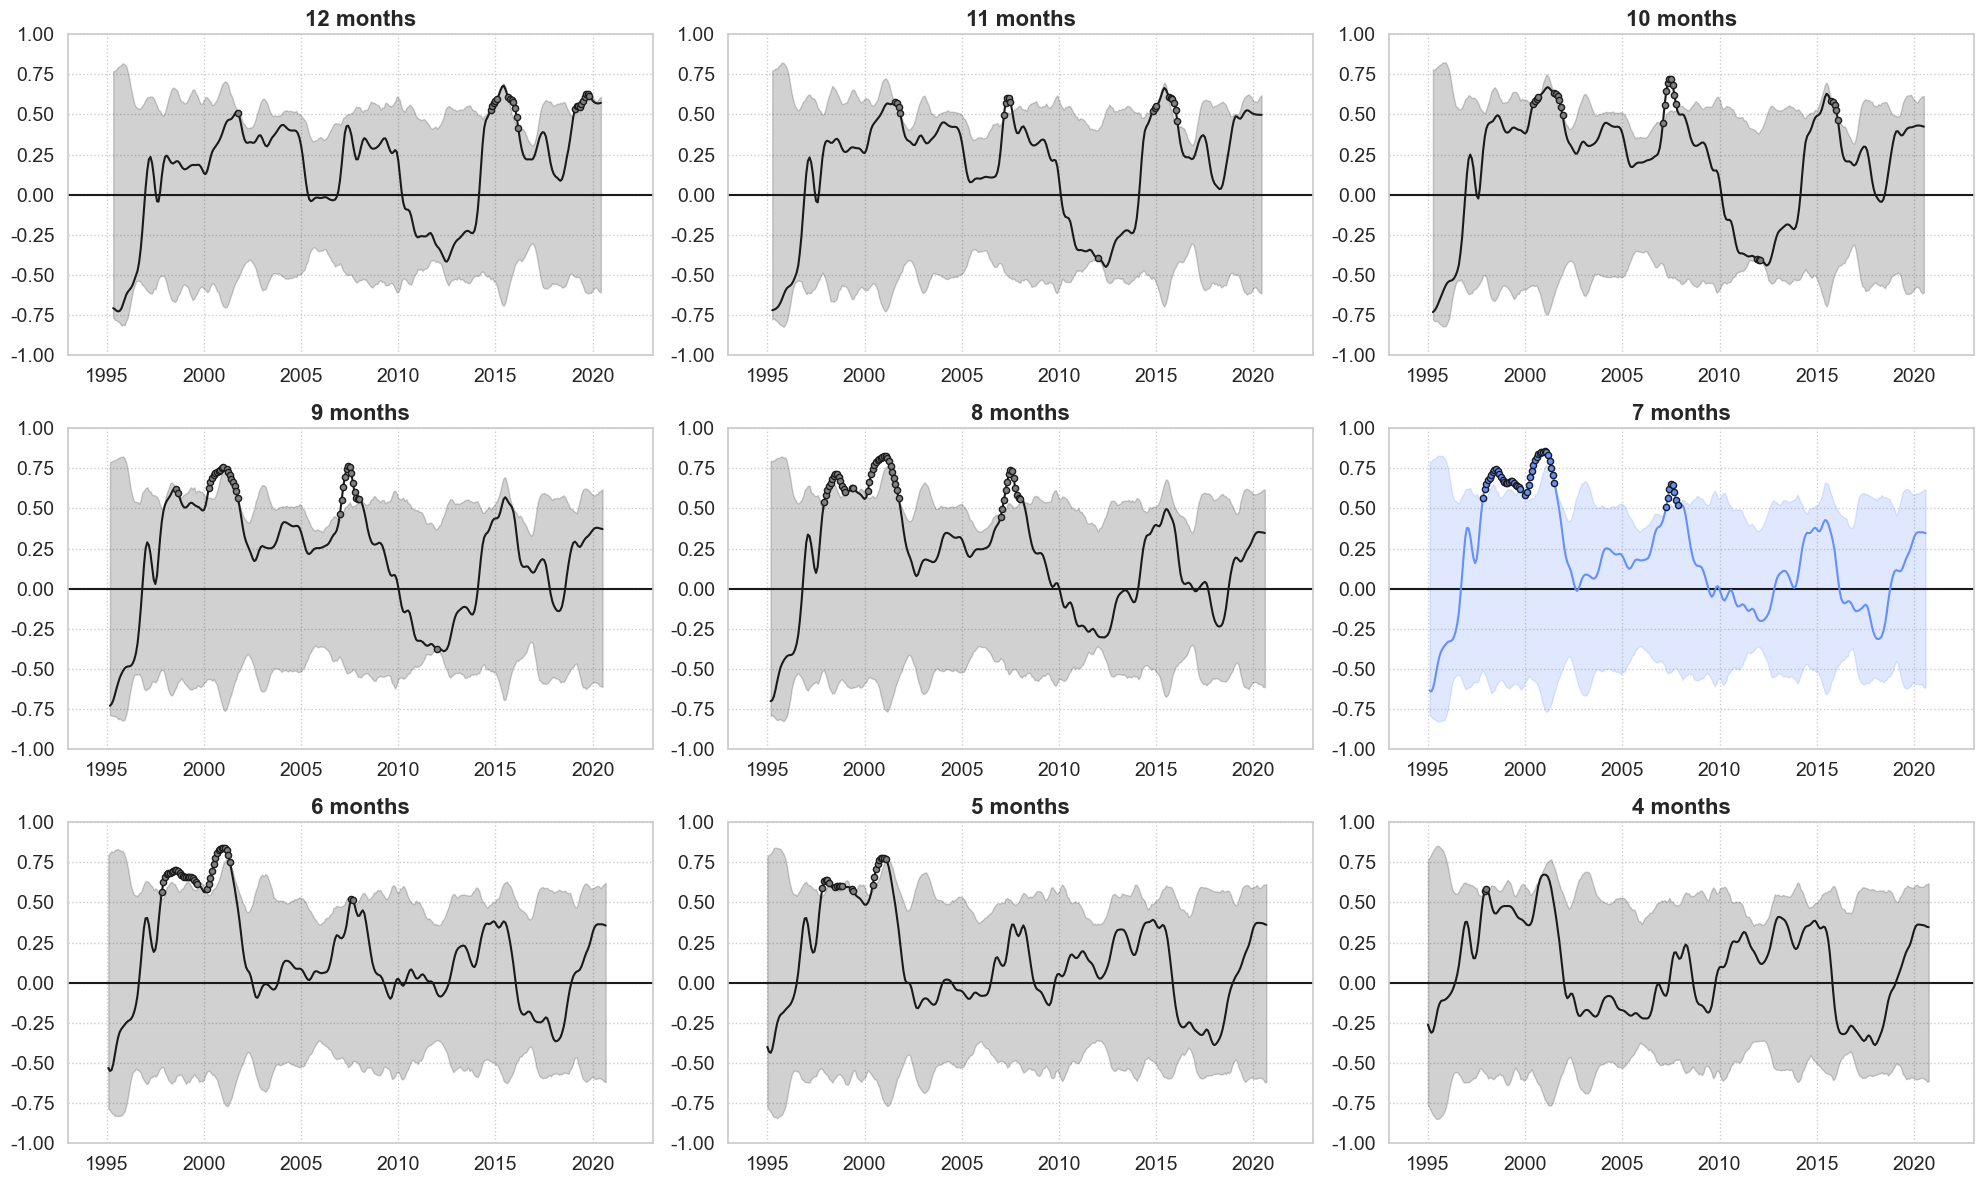

In [37]:
c = np.array(('k','k','k','k','k','#648fff','k','k','k'))
sc = np.array(('grey','grey','grey','grey','grey','#648fff','grey','grey','grey'))

sns.set_style('whitegrid',{"grid.linestyle": ":"})
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))
for row in range(3):
    for col in range(3):
        ch = row*3+col
        corr_temp = corrs_[ch,:][~np.isnan(corrs_[ch,:])]
        uci_temp  = uci_[ch,:][~np.isnan(uci_[ch,:])]
        lci_temp  = lci_[ch,:][~np.isnan(lci_[ch,:])]

        ix_ = []
        for l in range(len(corr_temp)):
            if corr_temp[l] < uci_temp[l] or corr_temp[l] > lci_temp[l]:
                ix_.append(l)
        ix_ = np.array(ix_)
        corr_temp = np.array(corr_temp)
        
        av_per    = len(gsi_f)-len(corr_temp)-lag_gs
        ax[row, col].axhline(0, color='k', linewidth=1.5)
        ax[row, col].plot(gsi_f.time[av_per//2:-av_per//2-lag_gs],corr_temp,color = c[ch])
        ax[row, col].fill_between(gsi_f.time[av_per//2:-av_per//2-lag_gs],lci_temp,uci_temp,color = c[ch],alpha = 0.2)
        ax[row, col].scatter(gsi_f.time[av_per//2:-av_per//2-lag_gs][ix_], corr_temp[ix_], s=20, color = sc[ch],edgecolors='k',zorder = 10)
        
        ax[row, col].set_xticks(gsi_f.time[2*12::5*12], labels = np.array(('1995','2000','2005','2010','2015','2020')), fontsize = 14)
        ax[row, col].set_yticks(np.arange(-1,1.25,0.25), labels = np.array(('-1.00','-0.75','-0.50','-0.25','0.00','0.25','0.50','0.75','1.00')), fontsize = 14)
        ax[row, col].set_xlim(gsi_f.time[0],gsi_f.time[-1])
        ax[row, col].set_ylim(-1,1)
        ax[row, col].set_title(str(lags_to_try[ch]) + ' months', fontsize = 16, fontweight='bold')

plt.tight_layout()
plt.savefig(fig_path + 'eap_lag_sensitivity.png', format='png', bbox_inches="tight",dpi=500)
plt.show()

## Final Choices

In [11]:
chunk_sz = 48
lag_gs   = 7
corrs_nao, lci_nao, uci_nao = moving_corr(nao_f, gsi_f, lag_gs, chunk_sz)
corrs_eap, lci_eap, uci_eap = moving_corr(eap_f, gsi_f, lag_gs, chunk_sz)

In [12]:
lci_nao = np.squeeze(np.stack(lci_nao)); uci_nao = np.squeeze(np.stack(uci_nao))
lci_eap = np.squeeze(np.stack(lci_eap)); uci_eap = np.squeeze(np.stack(uci_eap))

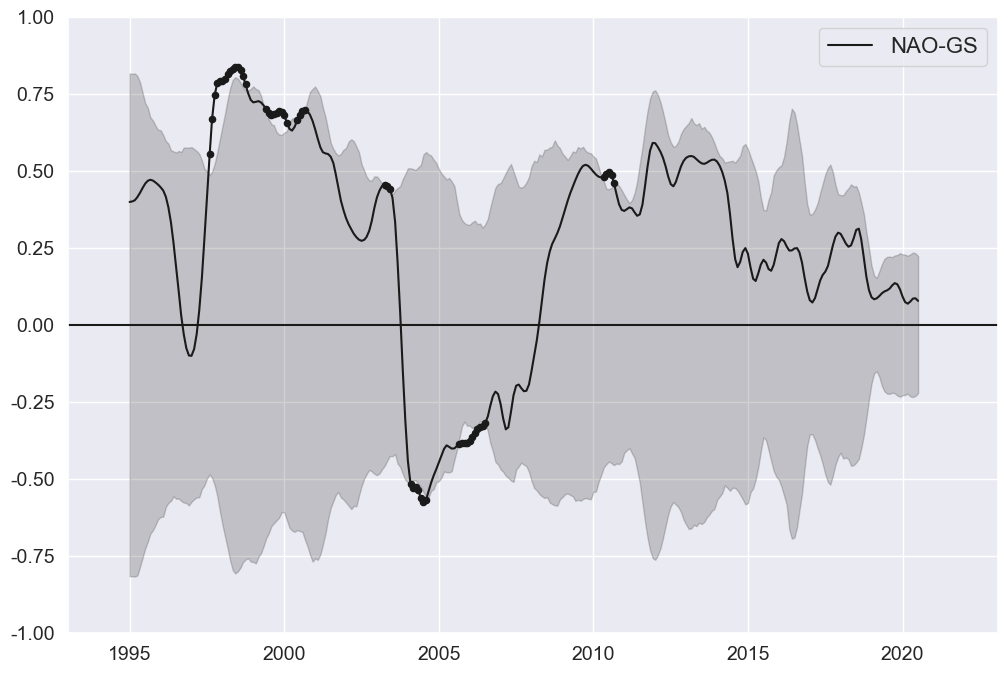

In [14]:
fig, ax = plt.subplots(figsize=(12, 8))
ix_nao = []
for l in range(len(corrs_nao)):
    if corrs_nao[l] > uci_nao[l] or corrs_nao[l] < lci_nao[l]:
        ix_nao.append(l)
ix_nao = np.array(ix_nao)
corrs_nao = np.array(corrs_nao)

ix_eap = []
for l in range(len(corrs_eap)):
    if corrs_eap[l] > uci_eap[l] or corrs_eap[l] < lci_eap[l]:
        ix_eap.append(l)
ix_eap = np.array(ix_eap)
corrs_eap = np.array(corrs_eap)

av_per    = len(gsi_f)-len(corrs_nao)-lag_gs
plt.axhline(0, color='k', linewidth=1.5)
plt.plot(gsi_f.time[av_per//2:-av_per//2-lag_gs],corrs_nao,color = 'k', label = 'NAO-GS')
plt.fill_between(gsi_f.time[av_per//2:-av_per//2-lag_gs],lci_nao,uci_nao,color = 'k',alpha = 0.2)
plt.scatter(gsi_f.time[av_per//2:-av_per//2-lag_gs][ix_nao], corrs_nao[ix_nao], s=20, color = 'k',edgecolors='k',zorder = 10)

#plt.plot(gsi_f.time[av_per//2:-av_per//2-lag_gs],corrs_eap,color = '#648fff', label = 'EAP-GS')
#plt.fill_between(gsi_f.time[av_per//2:-av_per//2-lag_gs],lci_eap,uci_eap,color = '#648fff',alpha = 0.2)
#plt.scatter(gsi_f.time[av_per//2:-av_per//2-lag_gs][ix_eap], corrs_eap[ix_eap], s=20, color = '#648fff',edgecolors='k',zorder = 10)

plt.xticks(gsi_f.time[2*12::5*12], labels = np.array(('1995','2000','2005','2010','2015','2020')), fontsize = 14)
plt.yticks(np.arange(-1,1.25,0.25), labels = np.array(('-1.00','-0.75','-0.50','-0.25','0.00','0.25','0.50','0.75','1.00')), fontsize = 14)
plt.xlim(gsi_f.time[0],gsi_f.time[-1])
plt.ylim(-1,1)
plt.legend(fontsize=16)
#plt.title('EAP & NAO Moving Correlations w GSI (r = ' + str('{:.2f}'.format(np.corrcoef(corrs_nao,corrs_eap)[0,1])) + ')', fontsize = 16, fontweight='bold')
plt.savefig(fig_path + 'nao_lag_moving_average.png', format='png', bbox_inches="tight",dpi=500)


In [ ]:
lags_to_try = abs(np.arange(-8,1))
corrs_   = np.zeros((len(lags_to_try),len(gsi_f))); corrs_[:] = np.nan
uci_     = np.zeros((len(lags_to_try),len(gsi_f))); uci_[:]   = np.nan
lci_     = np.zeros((len(lags_to_try),len(gsi_f))); lci_[:]   = np.nan
chunk_sz = 48

for l in range(len(lags_to_try)):
    print(lags_to_try[l])
    lag_gs = lags_to_try[l]
    corrs_temp, lci_temp, uci_temp = moving_corr(eap_f, gsi_f, lags_to_try[l], chunk_sz)
    corrs_temp.extend([np.nan] * (len(gsi_f) - len(corrs_temp)))
    corrs_[l,:] = corrs_temp
    lci_temp = np.squeeze(np.stack(lci_temp)); uci_temp = np.squeeze(np.stack(uci_temp))
    lci_[l,:] = np.pad(uci_temp, pad_width= (0,(len(gsi_f) - len(uci_temp))), constant_values=np.nan)
    uci_[l,:] = np.pad(lci_temp, pad_width= (0,(len(gsi_f) - len(lci_temp))), constant_values=np.nan)

In [ ]:
c = np.array(('k','k','k','k','k','#648fff','k','k','k'))
sc = np.array(('grey','grey','grey','grey','grey','#648fff','grey','grey','grey'))

sns.set_style('whitegrid',{"grid.linestyle": ":"})
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))
for row in range(3):
    for col in range(3):
        ch = row*3+col
        corr_temp = corrs_[ch,:][~np.isnan(corrs_[ch,:])]
        uci_temp  = uci_[ch,:][~np.isnan(uci_[ch,:])]
        lci_temp  = lci_[ch,:][~np.isnan(lci_[ch,:])]

        ix_ = []
        for l in range(len(corr_temp)):
            if corr_temp[l] < uci_temp[l] or corr_temp[l] > lci_temp[l]:
                ix_.append(l)
        ix_ = np.array(ix_)
        corr_temp = np.array(corr_temp)
        
        av_per    = len(gsi_f)-len(corr_temp)-lag_gs
        ax[row, col].axhline(0, color='k', linewidth=1.5)
        ax[row, col].plot(gsi_f.time[av_per//2:-av_per//2-lag_gs],corr_temp,color = c[ch])
        ax[row, col].fill_between(gsi_f.time[av_per//2:-av_per//2-lag_gs],lci_temp,uci_temp,color = c[ch],alpha = 0.2)
        ax[row, col].scatter(gsi_f.time[av_per//2:-av_per//2-lag_gs][ix_], corr_temp[ix_], s=20, color = sc[ch],edgecolors='k',zorder = 10)
        
        ax[row, col].set_xticks(gsi_f.time[2*12::5*12], labels = np.array(('1995','2000','2005','2010','2015','2020')), fontsize = 14)
        ax[row, col].set_yticks(np.arange(-1,1.25,0.25), labels = np.array(('-1.00','-0.75','-0.50','-0.25','0.00','0.25','0.50','0.75','1.00')), fontsize = 14)
        ax[row, col].set_xlim(gsi_f.time[0],gsi_f.time[-1])
        ax[row, col].set_ylim(-1,1)
        ax[row, col].set_title(str(lags_to_try[ch]) + ' months', fontsize = 16, fontweight='bold')

plt.tight_layout()
plt.savefig(fig_path + 'eap_lag_sensitivity.png', format='png', bbox_inches="tight",dpi=500)
plt.show()